# EDA

In [9]:
import pandas as pd

In [ ]:
kaggle_dataset = pd.read_csv("gold-dataset-sinha-khandait.csv")
kaggle_dataset.head()

,Dates,URL,News,Price Direction Up,Price Direction Constant,Price Direction Down,Asset Comparision,Past Information,Future Information,Price Sentiment
0,28-01-2016,http://www.marketwatch.com/story/april-gold-do...,"april gold down 20 cents to settle at $1,116.1...",0,0,1,0,1,0,negative
1,13-09-2017,http://www.marketwatch.com/story/gold-prices-s...,gold suffers third straight daily decline,0,0,1,0,1,0,negative
2,26-07-2016,http://www.marketwatch.com/story/gold-futures-...,Gold futures edge up after two-session decline,1,0,0,0,1,0,positive
3,28-02-2018,https://www.metalsdaily.com/link/277199/dent-r...,dent research : is gold's day in the sun comin...,0,0,0,0,0,1,none
4,06-09-2017,http://www.marketwatch.com/story/gold-steadies...,"Gold snaps three-day rally as Trump, lawmakers...",0,0,1,0,1,0,negative


In [ ]:
y_finance_dataset = pd.read_csv("YFinance_data.csv")
y_finance_dataset.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume,Pct_Change
0,1,2000-08-31,278.299988,278.299988,274.799988,274.799988,0,0.016064
1,2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,-0.004671
2,3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,-0.004332
3,4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,-0.005801
4,5,2000-09-07,274.000000,274.000000,274.000000,274.000000,125,-0.000729


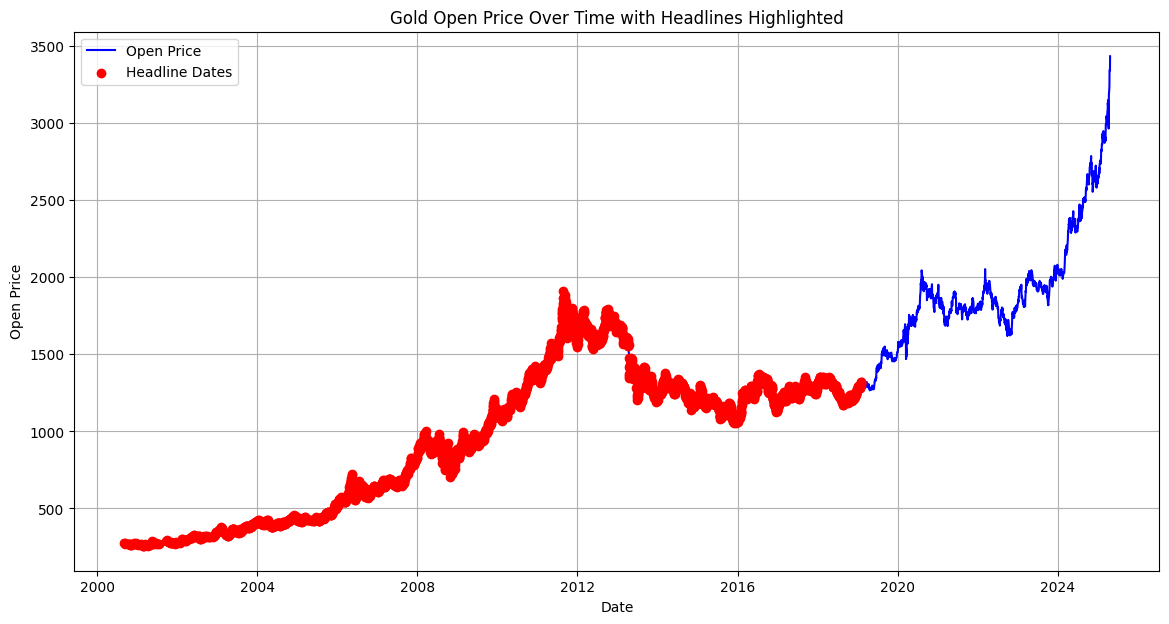

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

kaggle_dataset["Dates"] = pd.to_datetime(
    kaggle_dataset["Dates"], dayfirst=True, errors="coerce"
)
y_finance_dataset["Date"] = pd.to_datetime(y_finance_dataset["Date"])

y_finance_dataset.set_index("Date", inplace=True)

headline_dates = kaggle_dataset["Dates"]

plt.figure(figsize=(14, 7))
plt.plot(
    y_finance_dataset.index, y_finance_dataset["Open"], label="Open Price", color="blue"
)

headline_data = y_finance_dataset.loc[y_finance_dataset.index.isin(headline_dates)]
plt.scatter(
    headline_data.index,
    headline_data["Open"],
    color="red",
    label="Headline Dates",
    zorder=5,
)

plt.title("Gold Open Price Over Time with Headlines Highlighted")
plt.xlabel("Date")
plt.ylabel("Open Price")
plt.legend()
plt.grid(True)
plt.show()

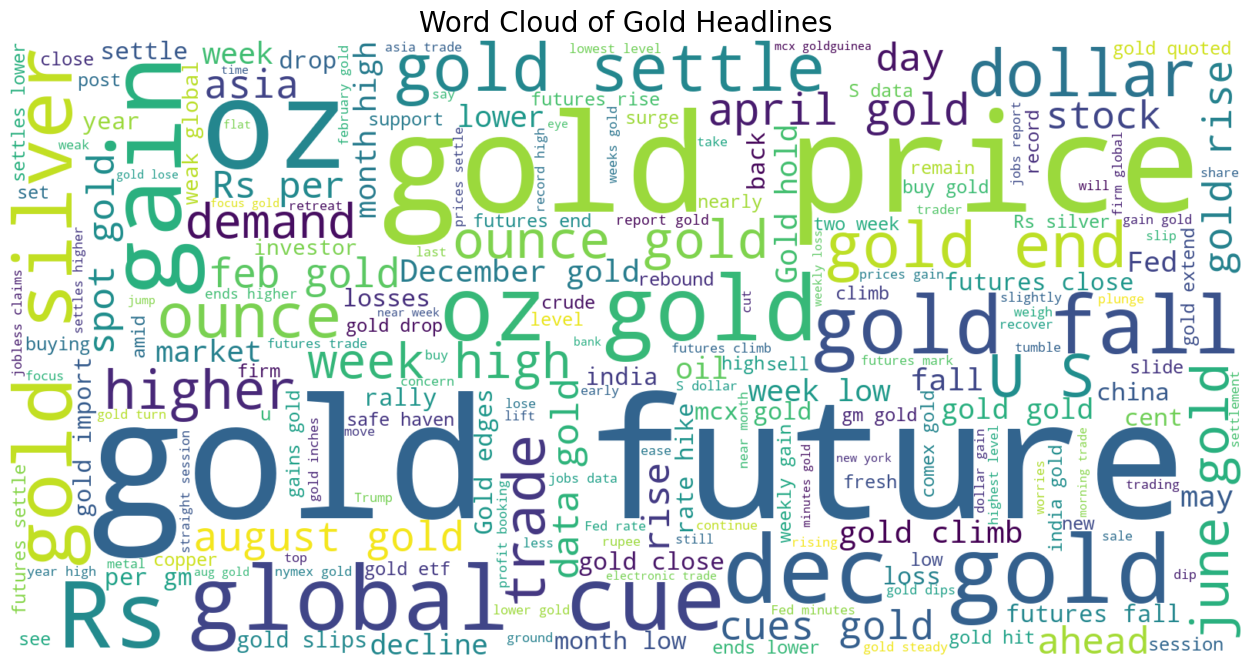

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(kaggle_dataset["News"].dropna())

wordcloud = WordCloud(
    width=1600, height=800, background_color="white", colormap="viridis", max_words=200
).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Gold Headlines", fontsize=20)
plt.show()

/var/folders/mc/2wjfdchj6vsffbrpfbfgqw4w0000gn/T/ipykernel_15900/2820601682.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  headline_counts = kaggle_dataset['News'].resample('M').count()


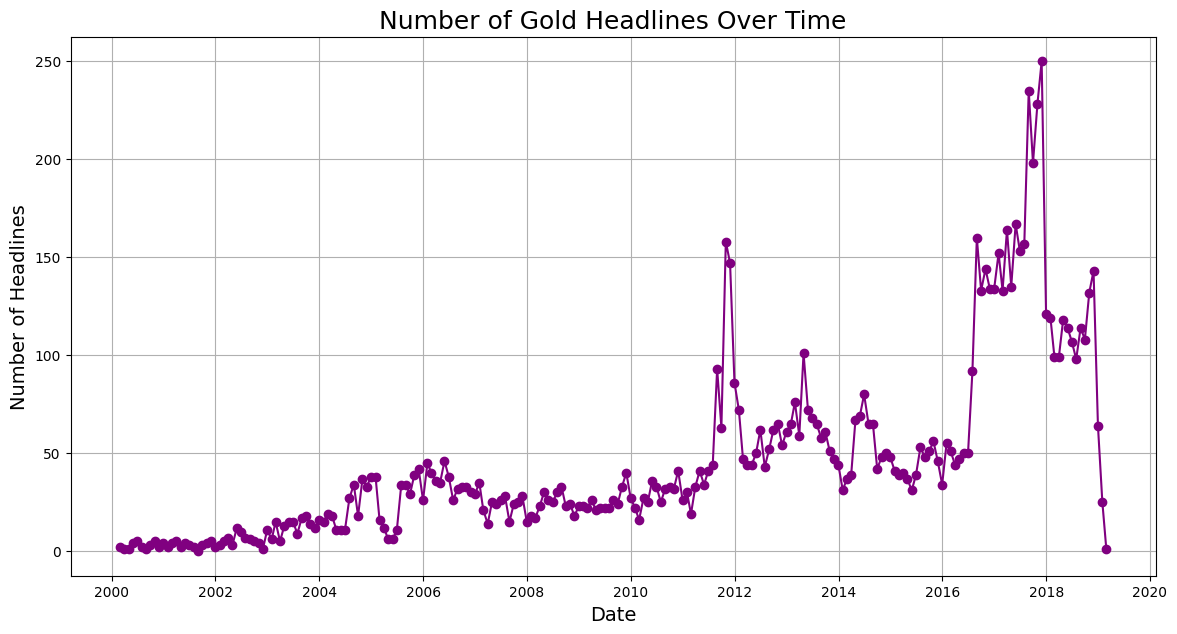

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

kaggle_dataset["Dates"] = pd.to_datetime(
    kaggle_dataset["Dates"], dayfirst=True, errors="coerce"
)
kaggle_dataset = kaggle_dataset.dropna(subset=["Dates"])

kaggle_dataset.set_index("Dates", inplace=True)

headline_counts = kaggle_dataset["News"].resample("M").count()

plt.figure(figsize=(14, 7))
plt.plot(
    headline_counts.index,
    headline_counts.values,
    marker="o",
    linestyle="-",
    color="purple",
)
plt.title("Number of Gold Headlines Over Time", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of Headlines", fontsize=14)
plt.grid(True)
plt.show()